# Análise dos resultados de segmentação e detecção dos óstios

## Objetivo

Este notebook realiza uma análise exploratória dos resultados da segmentação dos óstios a partir do pipeline. São apresentados gráficos e estatísticas para avaliar a qualidade das segmentações.

Resume status dos óstios, distâncias e Dice dos resultados canônicos de treino, validação e teste.

In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent,
    NOTEBOOK_CWD.parent.parent,
):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.project.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment()

In [2]:
import pandas as pd

from utils.project.notebook_env import get_default_split_paths
from utils.comparison_utils import filter_correct_ostia_cases, load_split_results
from utils.visualization.comparison import (
    plot_dice_distribution_by_subset,
    plot_dice_distribution_for_publication,
)
from utils.visualization.segmentation_eda import (
    build_success_status_summary_by_subset,
    plot_distance_distribution_by_subset,
    plot_status_distribution_by_subset,
    plot_success_error_by_subset,
)

SUCCESS_STATUS = ["both_tolerable", "both_correct"]
BAD_OSTIA_STATUS = ["óstios não encontrados", "óstios ruins (bloqueado)"]

## Configuração

Ajuste nesta seção apenas os parâmetros da análise; o pipeline base não é alterado.

## Carregamento dos Dados
Os dados de saída do pipeline são carregados a partir do arquivo CSV gerado, contendo as informações de status e coordenadas dos óstios para cada imagem.

In [3]:
SPLIT_PATHS_BY_RESOLUTION = get_default_split_paths(REPO_ROOT)
VALID_SPLITS = ("train", "val", "test")
RESOLUTION_KEYS = {"high": "high_res", "mid": "mid_res"}

# Carregar todos os dados diretamente pelo helper compartilhado.
data = {
    resolution: {
        split: load_split_results(
            SPLIT_PATHS_BY_RESOLUTION,
            resolution_key,
            split,
        )
        for split in VALID_SPLITS
    }
    for resolution, resolution_key in RESOLUTION_KEYS.items()
}

# Dataset atualmente ativo (padrão: mid/train)
current_resolution = "mid"
current_split = "train"
df = data[current_resolution][current_split]

available_pairs = [
    f"{resolution}/{split}"
    for resolution, split_data in data.items()
    for split, split_df in split_data.items()
    if split_df is not None
]
print("Dados carregados com sucesso!")
print("\nResolução e split disponíveis:", ", ".join(available_pairs))
print(f"Dados ativos: {current_resolution}/{current_split}")
df.head()

Dados carregados com sucesso!

Resolução e split disponíveis: high/train, high/val, high/test, mid/train, mid/val, mid/test
Dados ativos: mid/train


,IMG_ID,artery_dice,artery_dice_before_morphology,artery_dice_after_morphology,artery_dice_morphology_delta,artery_voxel_count,artery_voxel_count_before_morphology,artery_voxel_count_after_morphology,artery_left_raw_voxels,artery_right_raw_voxels,...,ostia_error,both_correct,both_tolerable,left_intersects,right_intersects,left_dist_mm,right_dist_mm,ostia_left,ostia_right,error
0,28,0.670966,0.367107,0.670966,0.303859,24661,6046,24661,NaN,NaN,...,NaN,False,True,False,False,1.073700,0.837506,"(103, 144, 181)","(128, 115, 217)",NaN
1,380,0.552022,0.298061,0.552022,0.253961,42258,9855,42258,NaN,NaN,...,NaN,False,True,False,False,2.349540,1.739843,"(93, 120, 120)","(113, 89, 166)",NaN
2,854,0.631307,0.350654,0.631307,0.280653,30979,6800,30979,NaN,NaN,...,NaN,False,True,False,False,1.273438,0.636719,"(99, 151, 157)","(124, 117, 185)",NaN
3,937,0.684926,0.372990,0.684926,0.311936,28809,6321,28809,NaN,NaN,...,NaN,False,True,False,False,1.390625,2.160393,"(106, 170, 209)","(115, 129, 227)",NaN
4,315,0.646433,0.327657,0.646433,0.318776,28774,6371,28774,NaN,NaN,...,NaN,False,True,True,False,0.000000,0.500000,"(100, 179, 144)","(115, 146, 217)",NaN


## Análise

As subseções abaixo apresentam as métricas, tabelas ou visualizações do objetivo definido.

## Distribuição dos Status de Segmentação

### Treino (Train)

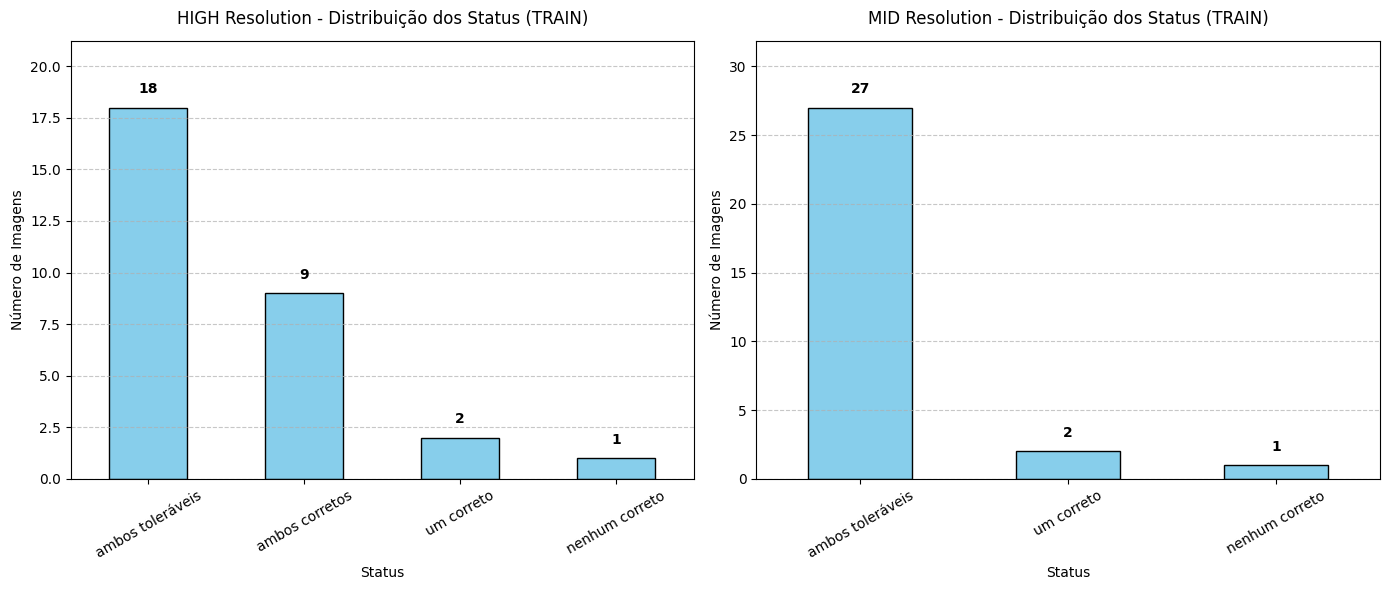

In [4]:
plot_status_distribution_by_subset(data, "train")

### Validação (Val)

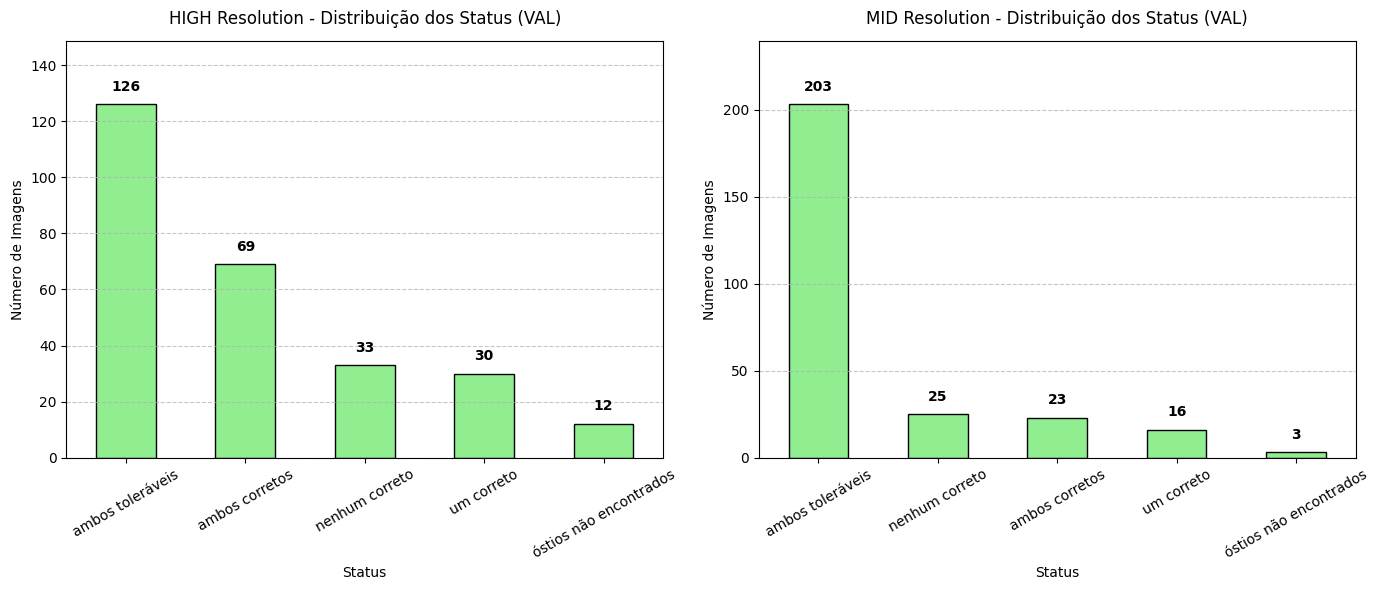

In [5]:
plot_status_distribution_by_subset(data, "val")

### Teste (Test)

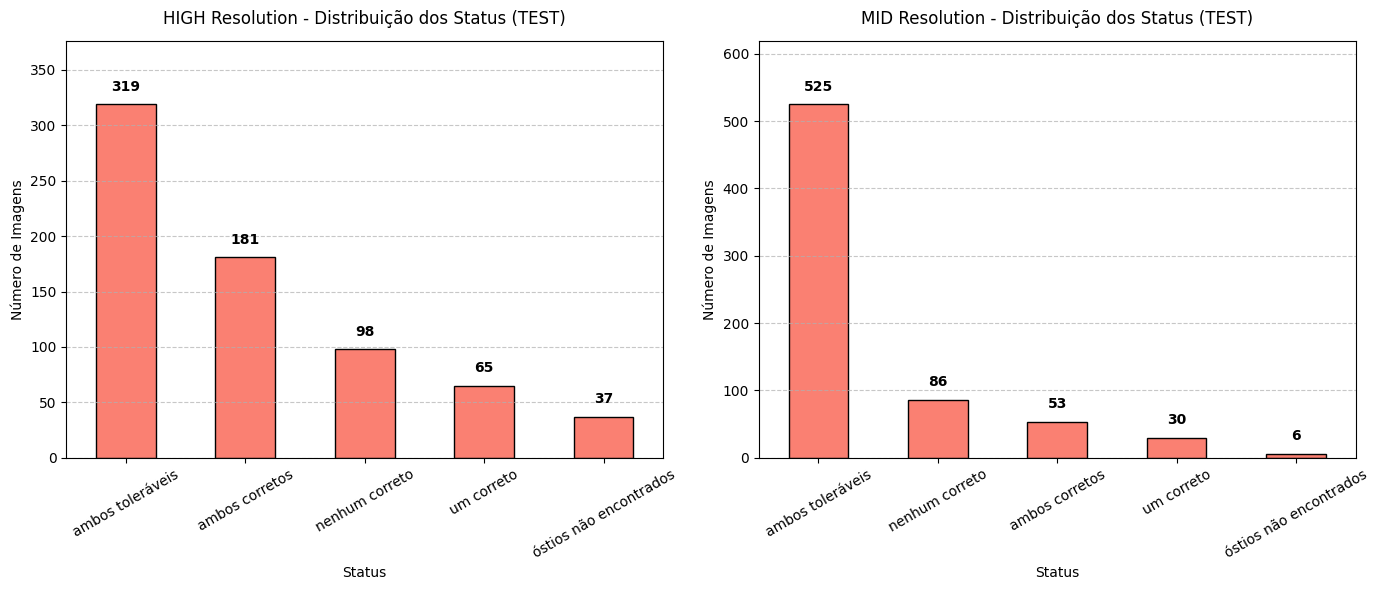

In [6]:
plot_status_distribution_by_subset(data, "test")

## Acertos e Erros na Segmentação

### Treino (Train)

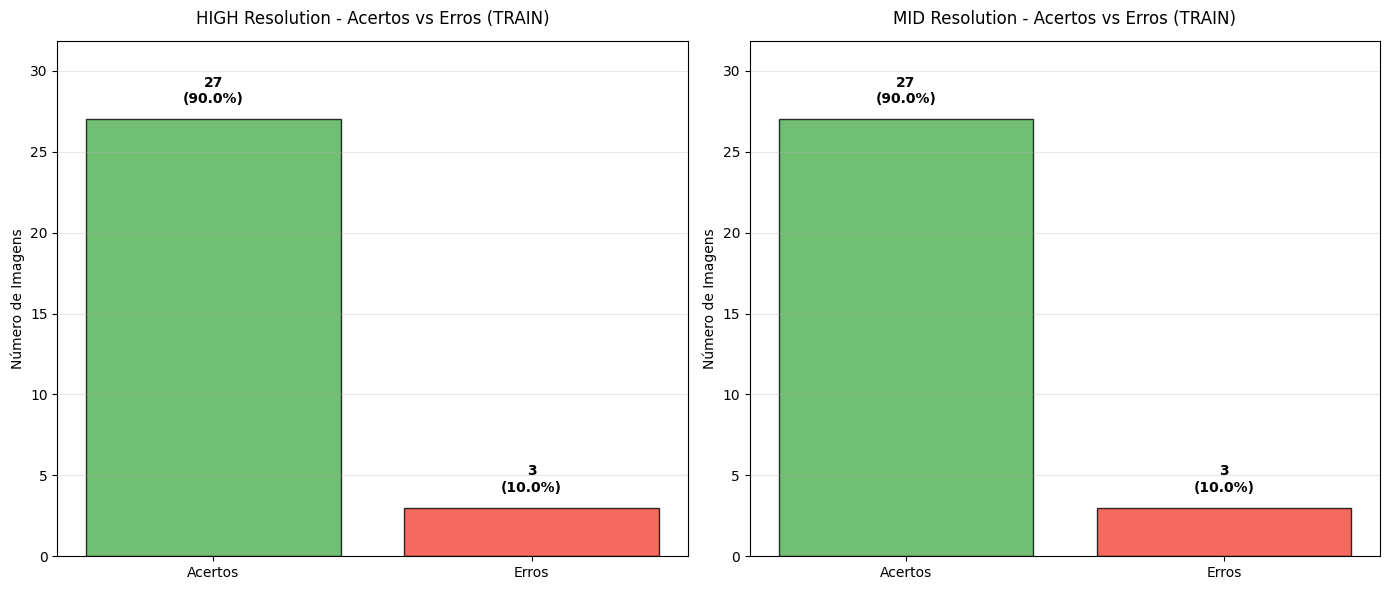

,split,resolution,status,quantidade,percentual_do_total,total_acertos,total_imagens
0,train,high,ambos toleráveis,18,60.0,27,30
1,train,high,ambos corretos,9,30.0,27,30
2,train,high,total acertos,27,90.0,27,30
3,train,mid,ambos toleráveis,27,90.0,27,30
4,train,mid,ambos corretos,0,0.0,27,30
5,train,mid,total acertos,27,90.0,27,30


In [7]:
plot_success_error_by_subset(data, "train", SUCCESS_STATUS)
build_success_status_summary_by_subset(data, "train", SUCCESS_STATUS)

### Validação (Val)

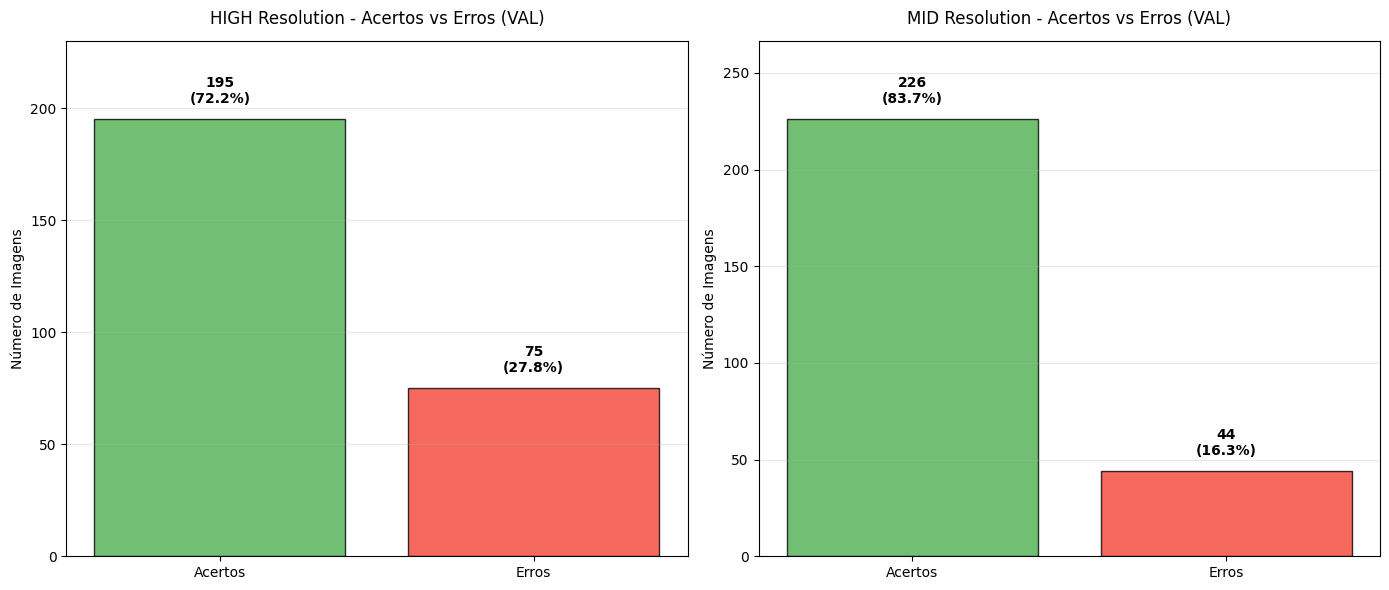

,split,resolution,status,quantidade,percentual_do_total,total_acertos,total_imagens
0,val,high,ambos toleráveis,126,46.67,195,270
1,val,high,ambos corretos,69,25.56,195,270
2,val,high,total acertos,195,72.22,195,270
3,val,mid,ambos toleráveis,203,75.19,226,270
4,val,mid,ambos corretos,23,8.52,226,270
5,val,mid,total acertos,226,83.70,226,270


In [8]:
plot_success_error_by_subset(data, "val", SUCCESS_STATUS)
build_success_status_summary_by_subset(data, "val", SUCCESS_STATUS)

### Teste (Test)

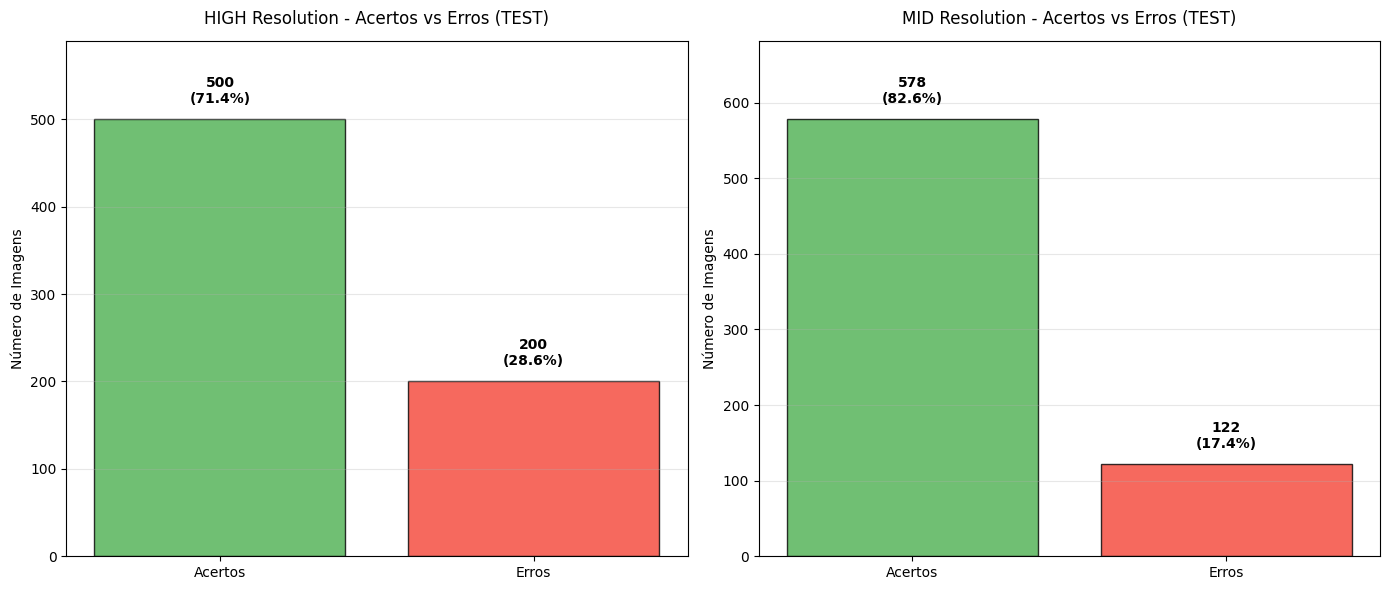

,split,resolution,status,quantidade,percentual_do_total,total_acertos,total_imagens
0,test,high,ambos toleráveis,319,45.57,500,700
1,test,high,ambos corretos,181,25.86,500,700
2,test,high,total acertos,500,71.43,500,700
3,test,mid,ambos toleráveis,525,75.00,578,700
4,test,mid,ambos corretos,53,7.57,578,700
5,test,mid,total acertos,578,82.57,578,700


In [9]:
plot_success_error_by_subset(data, "test", SUCCESS_STATUS)
build_success_status_summary_by_subset(data, "test", SUCCESS_STATUS)

## Distribuição das Distâncias Left e Right (mm)

A linha tracejada vermelha em **7 mm** representa o limite de tolerância adotado para considerar a detecção do óstio como aceitável.

### Treino (Train)


HIGH - TRAIN
  Left Distance: 29 abaixo de 7.0mm, 1 acima
  Right Distance: 28 abaixo de 7.0mm, 2 acima

MID - TRAIN
  Left Distance: 29 abaixo de 7.0mm, 1 acima
  Right Distance: 28 abaixo de 7.0mm, 2 acima


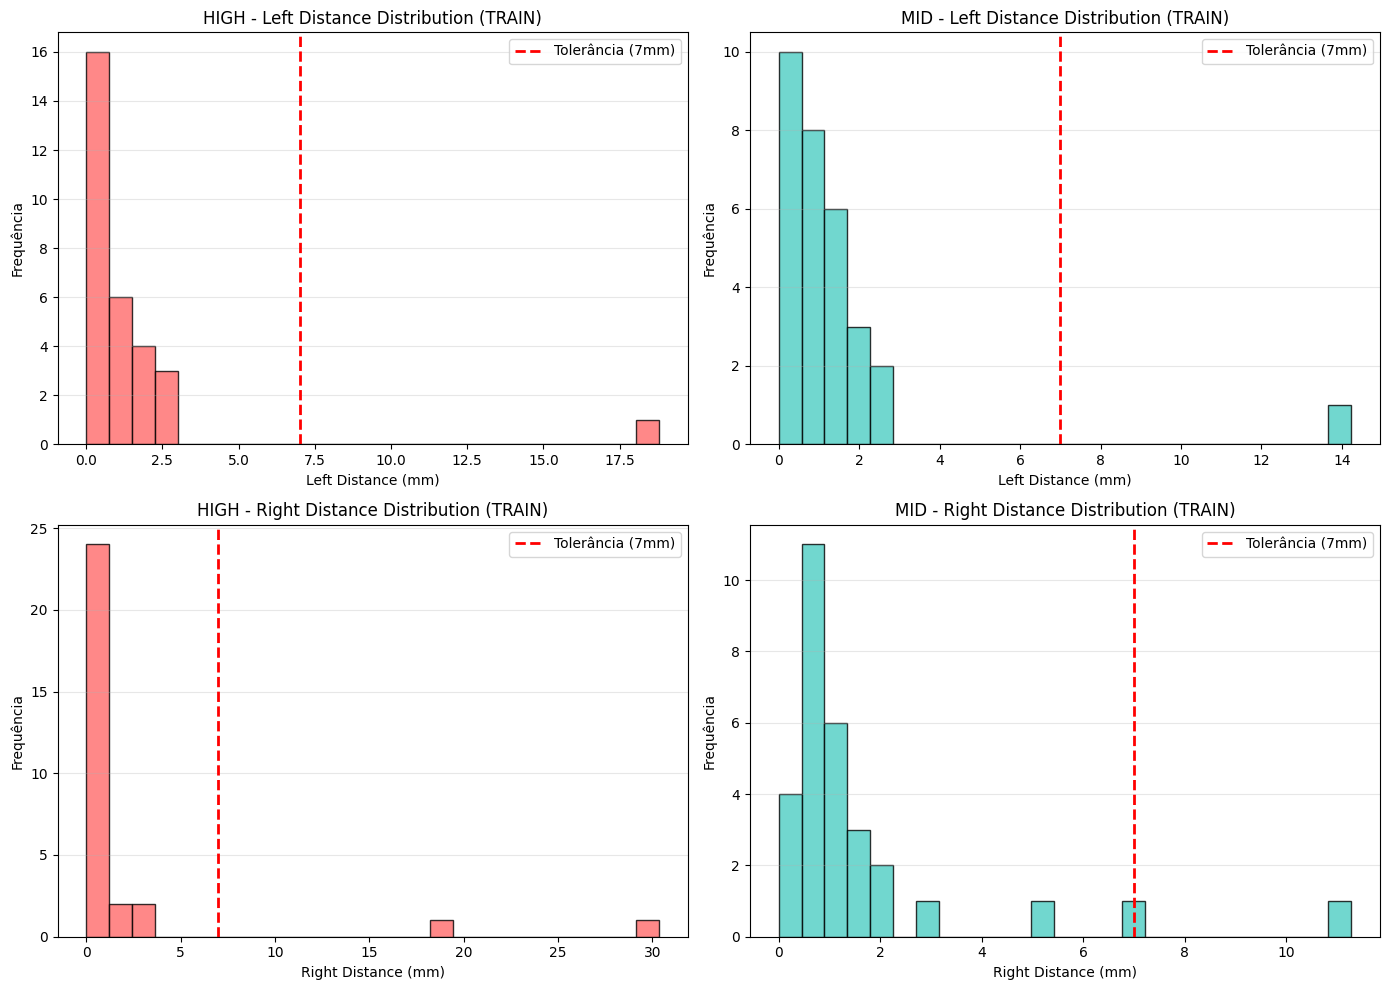

In [10]:
plot_distance_distribution_by_subset(data, "train", bins=25)

### Validação (Val)


HIGH - VAL
  Left Distance: 227 abaixo de 7.0mm, 31 acima
  Right Distance: 211 abaixo de 7.0mm, 47 acima

MID - VAL
  Left Distance: 249 abaixo de 7.0mm, 18 acima
  Right Distance: 235 abaixo de 7.0mm, 31 acima


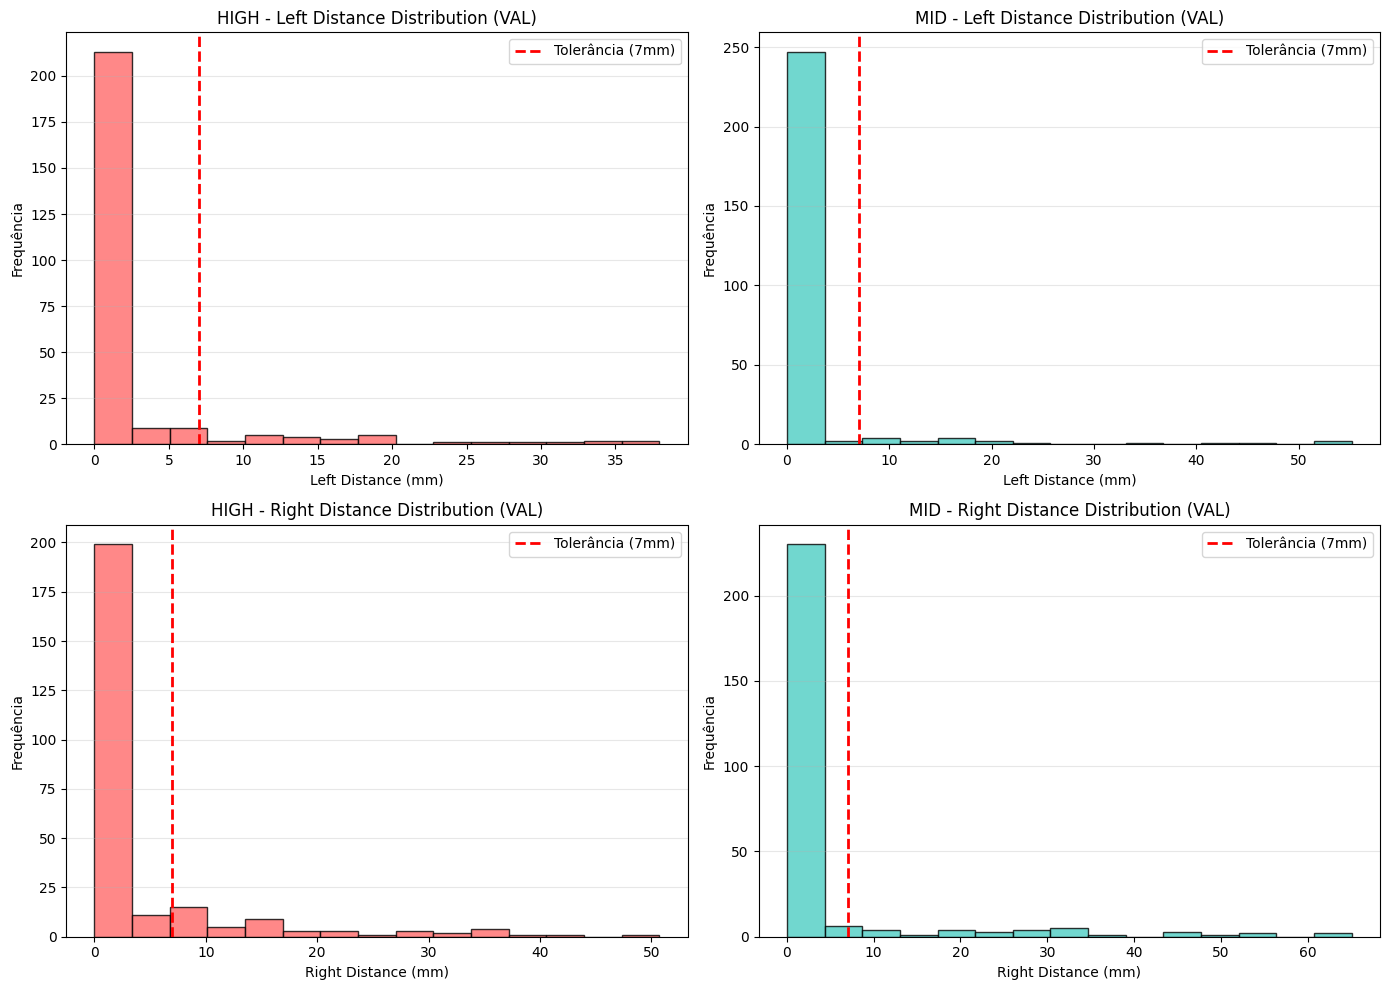

In [11]:
plot_distance_distribution_by_subset(data, "val", bins=15)

### Teste (Test)


HIGH - TEST
  Left Distance: 574 abaixo de 7.0mm, 89 acima
  Right Distance: 550 abaixo de 7.0mm, 113 acima

MID - TEST
  Left Distance: 638 abaixo de 7.0mm, 56 acima
  Right Distance: 608 abaixo de 7.0mm, 84 acima


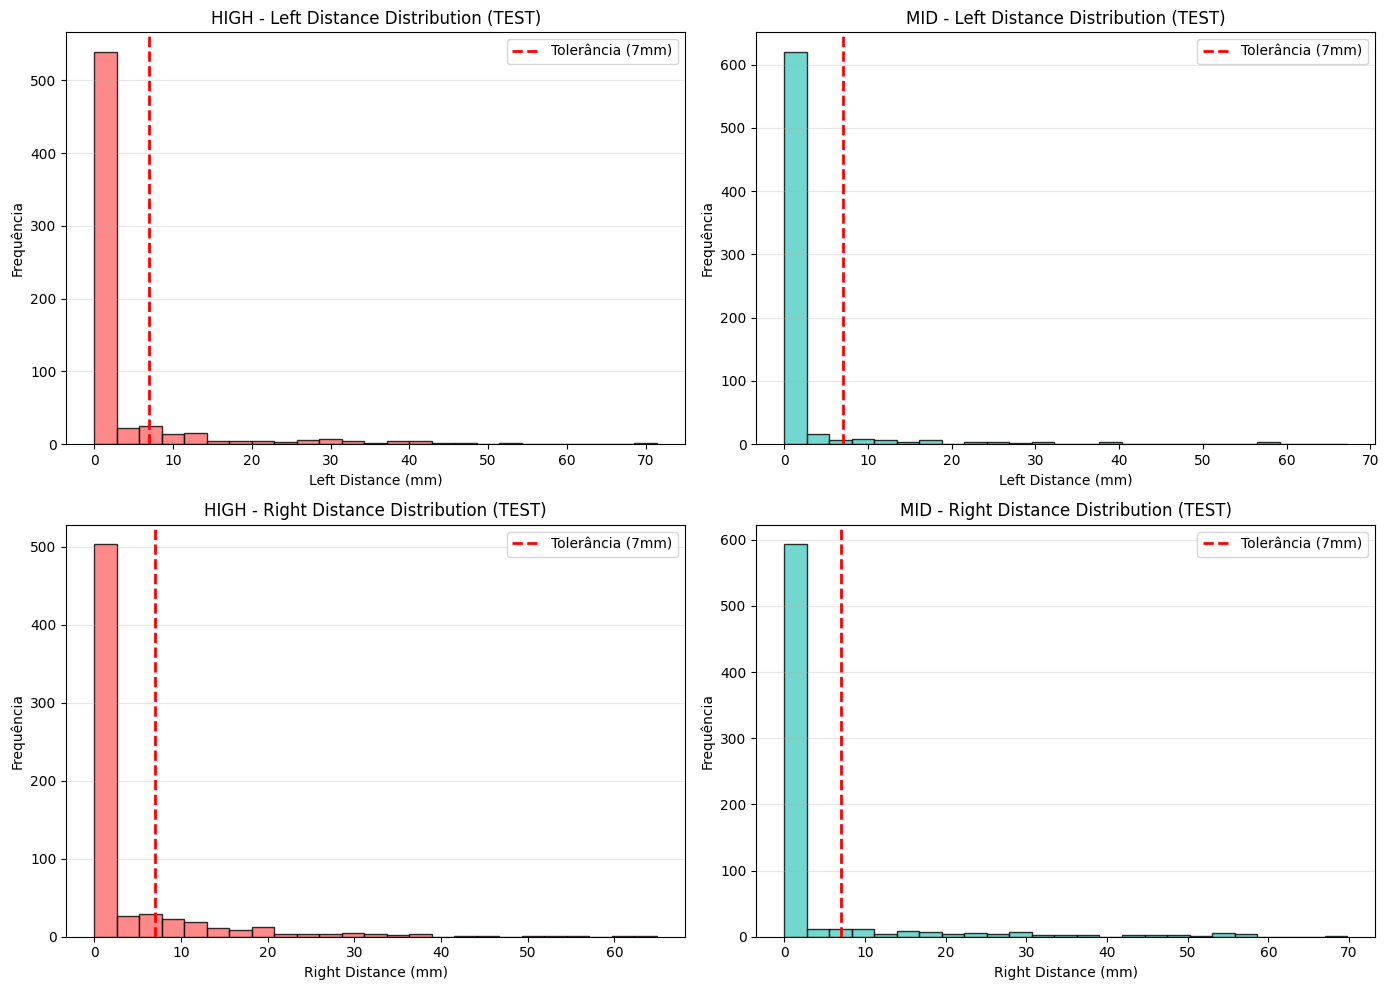

In [12]:
plot_distance_distribution_by_subset(data, "test", bins=25)

## Distribuição do Dice Score

### Treino (Train)

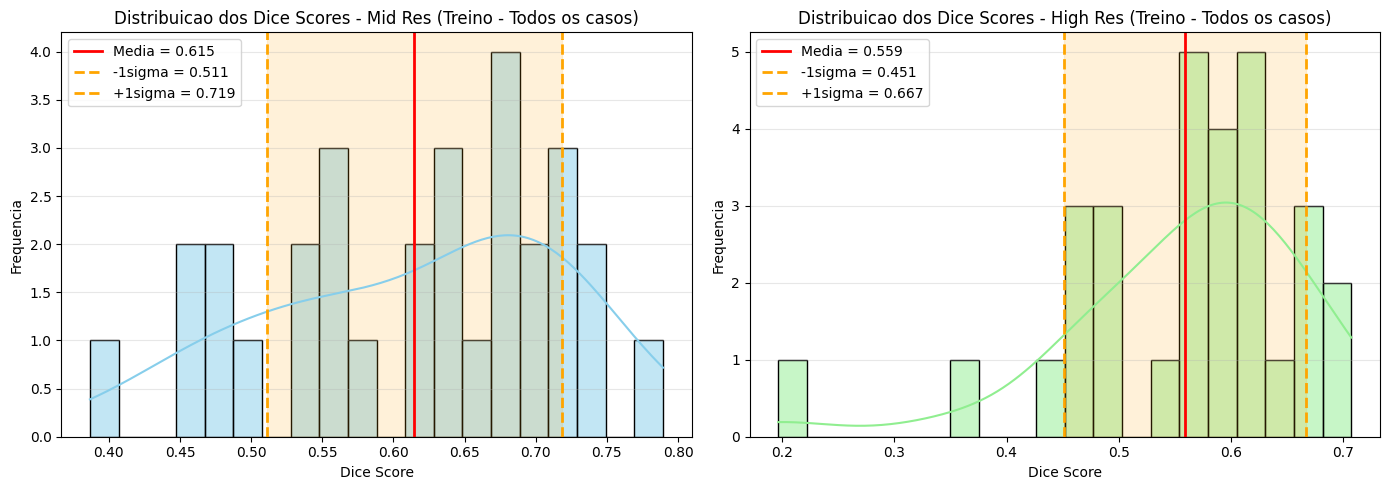

In [13]:
plot_dice_distribution_by_subset(
    data["mid"]["train"], data["high"]["train"], "Treino - Todos os casos"
)

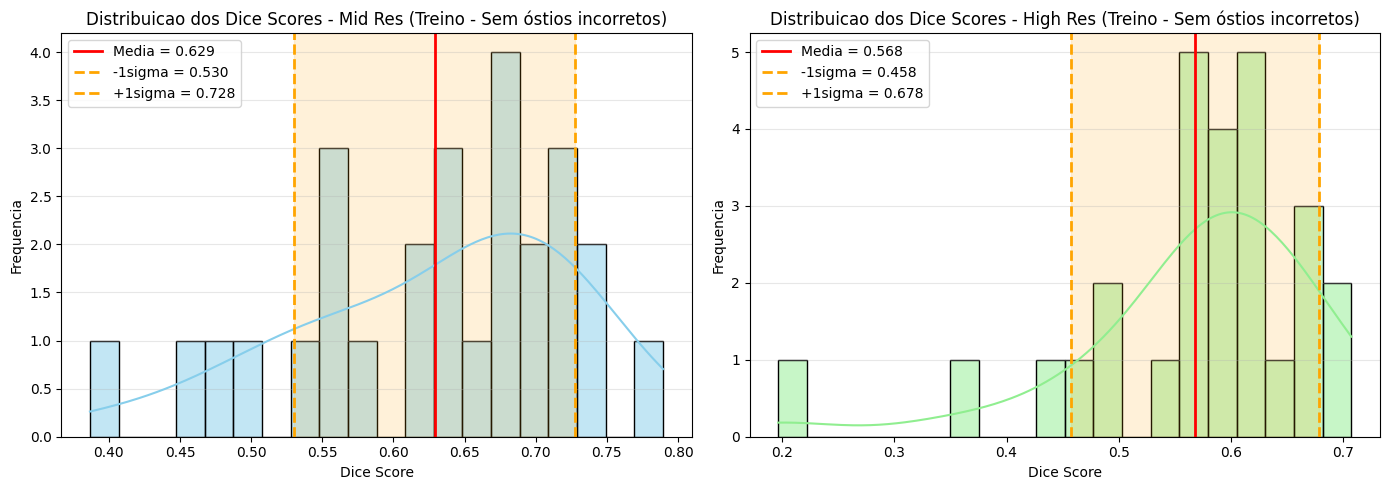

In [14]:
plot_dice_distribution_by_subset(
    filter_correct_ostia_cases(data["mid"]["train"]),
    filter_correct_ostia_cases(data["high"]["train"]),
    "Treino - Sem óstios incorretos",
)

### Validação (Val)

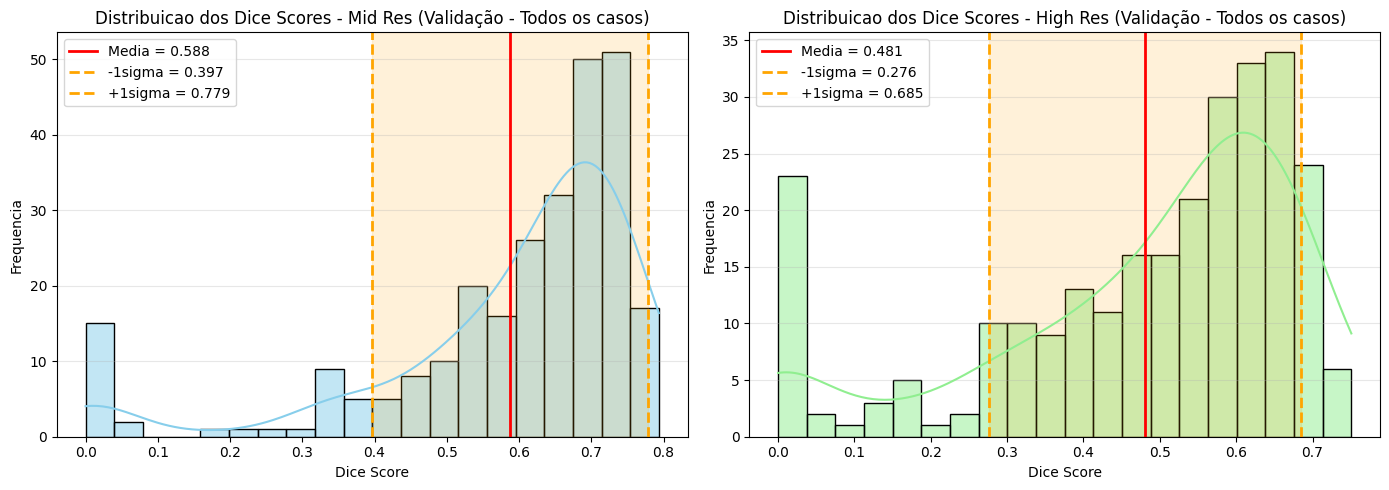

In [15]:
plot_dice_distribution_by_subset(
    data["mid"]["val"], data["high"]["val"], "Validação - Todos os casos"
)

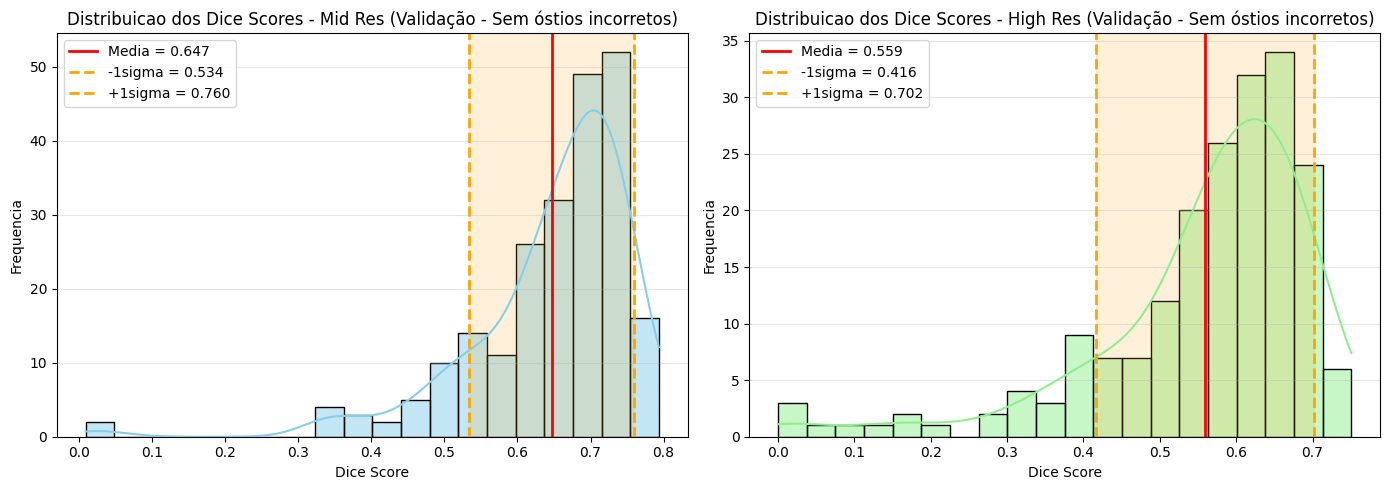

In [16]:
plot_dice_distribution_by_subset(
    filter_correct_ostia_cases(data["mid"]["val"]),
    filter_correct_ostia_cases(data["high"]["val"]),
    "Validação - Sem óstios incorretos",
)

### Teste (Test)

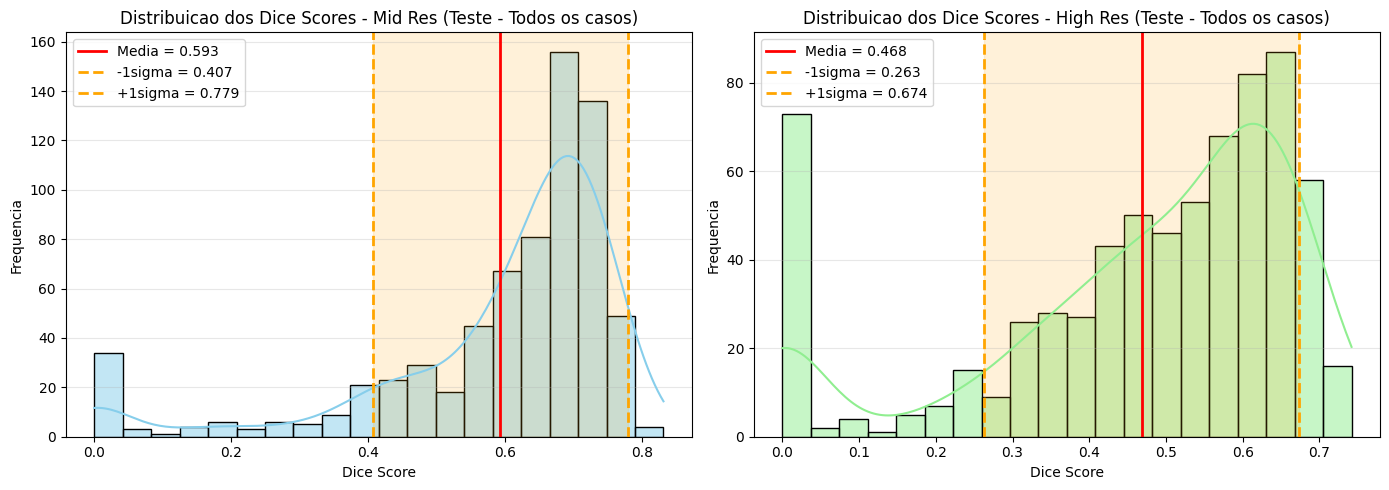

In [17]:
plot_dice_distribution_by_subset(
    data["mid"]["test"], data["high"]["test"], "Teste - Todos os casos"
)

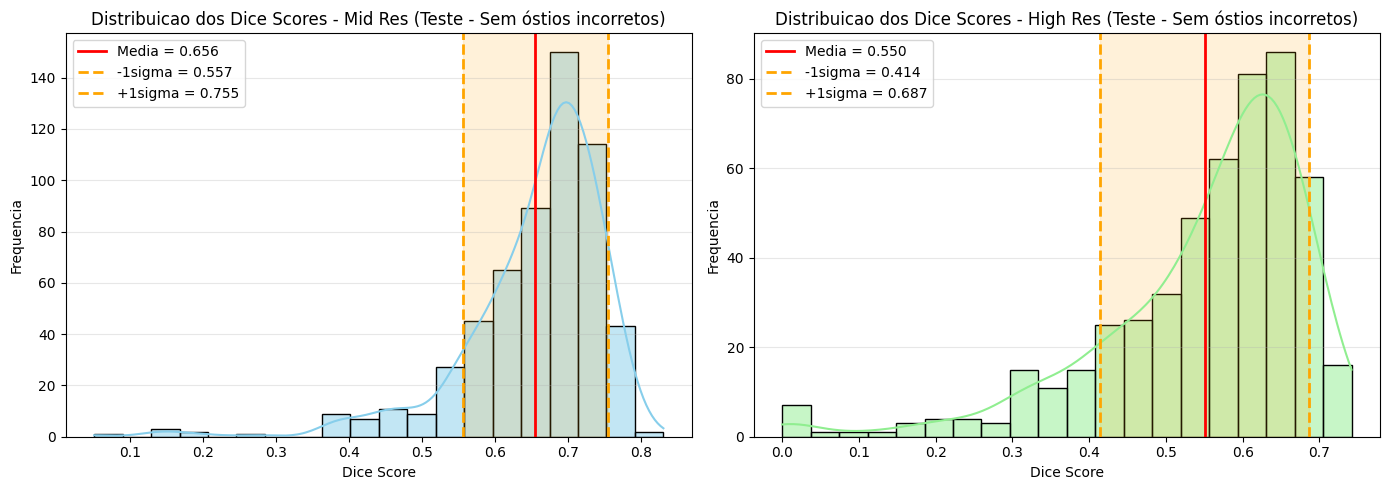

In [18]:
plot_dice_distribution_by_subset(
    filter_correct_ostia_cases(data["mid"]["test"]),
    filter_correct_ostia_cases(data["high"]["test"]),
    "Teste - Sem óstios incorretos",
)

## Figuras de Dice em mid resolution para publicação
As celulas abaixo geram figuras em alta resolucao separando os casos com sucesso de ostios e os casos com ostios incorretos.


In [19]:
TEMP_FIGURE_DPI = 400
TEMP_DICE_SPLIT = "test"


def build_mid_dice_subset(
    only_correct_ostia: bool,
    split: str = TEMP_DICE_SPLIT,
) -> pd.DataFrame:
    subset = data["mid"][split].copy()
    if only_correct_ostia:
        subset = filter_correct_ostia_cases(subset)
    subset["dice_artery"] = pd.to_numeric(subset["dice_artery"], errors="coerce")
    return subset.dropna(subset=["dice_artery"])

{'count': 700, 'mean': 0.593019889302077, 'std': 0.186329230678275}


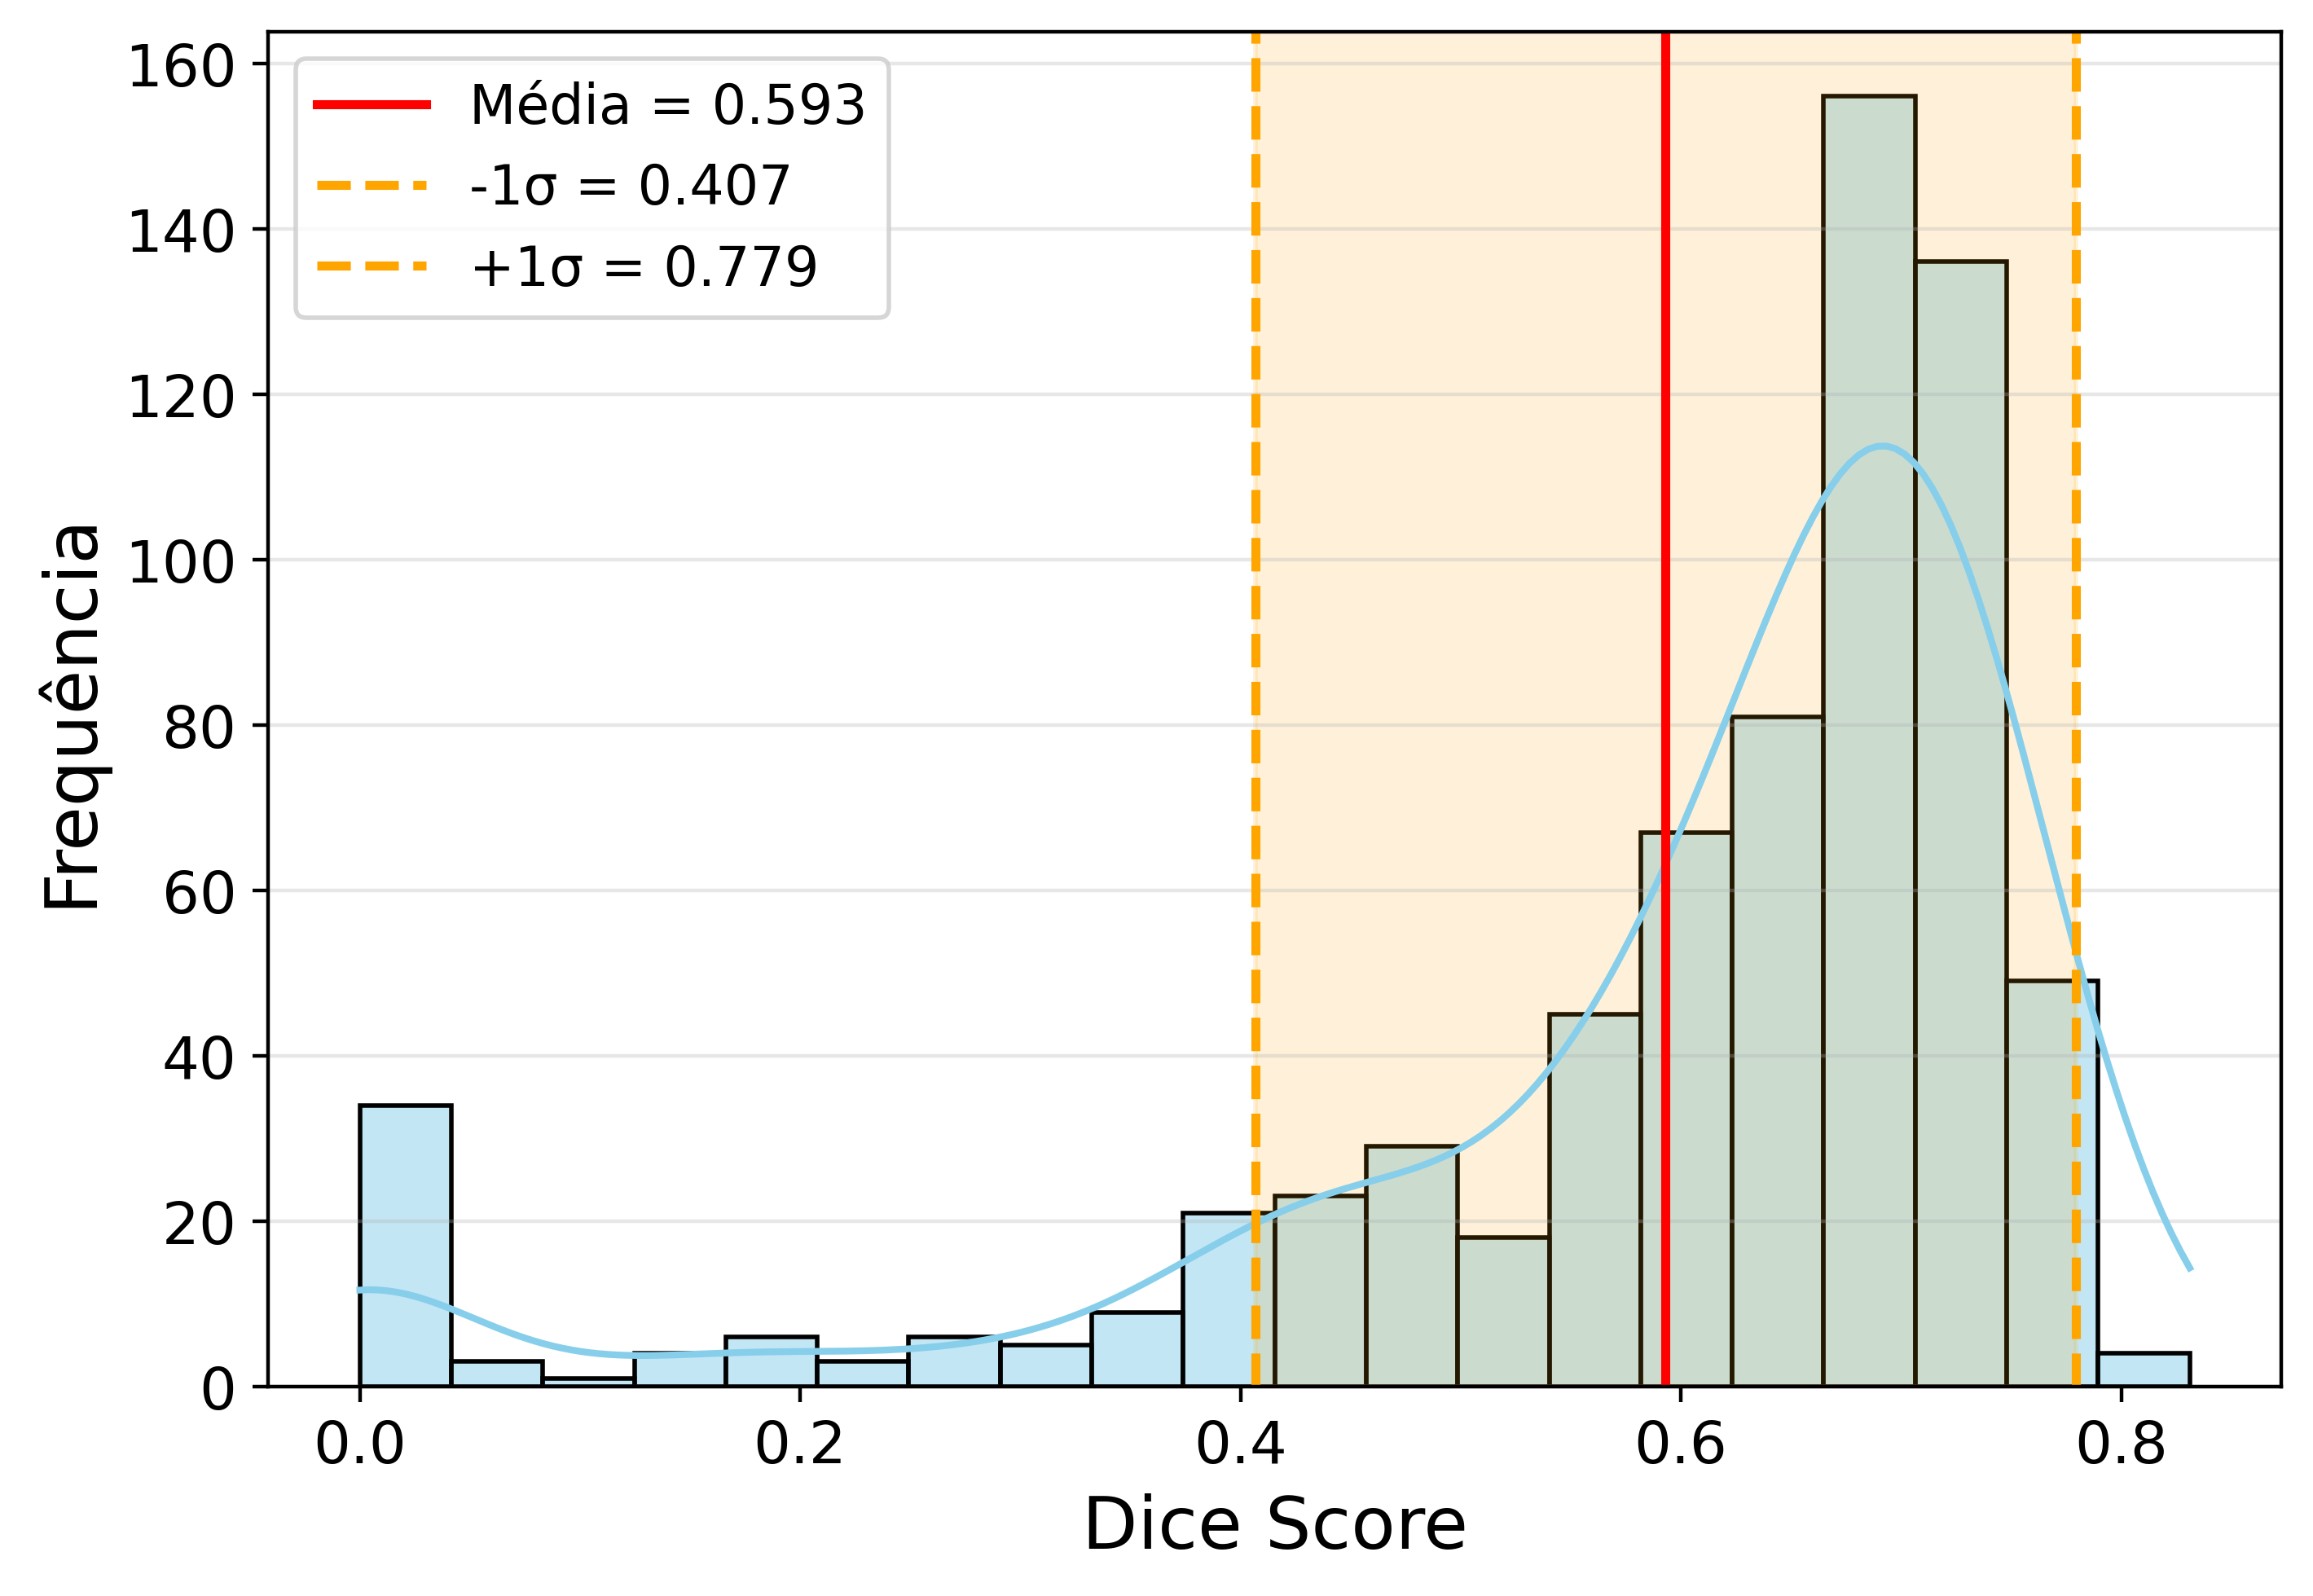

In [20]:
mid_dice_all_cases_df = build_mid_dice_subset(only_correct_ostia=False)
_, all_cases_stats = plot_dice_distribution_for_publication(
    mid_dice_all_cases_df["dice_artery"],
    output_path=None,
    dpi=TEMP_FIGURE_DPI,
)
print(all_cases_stats)

{'count': 578, 'mean': 0.6557571762244346, 'std': 0.09898021193928508}


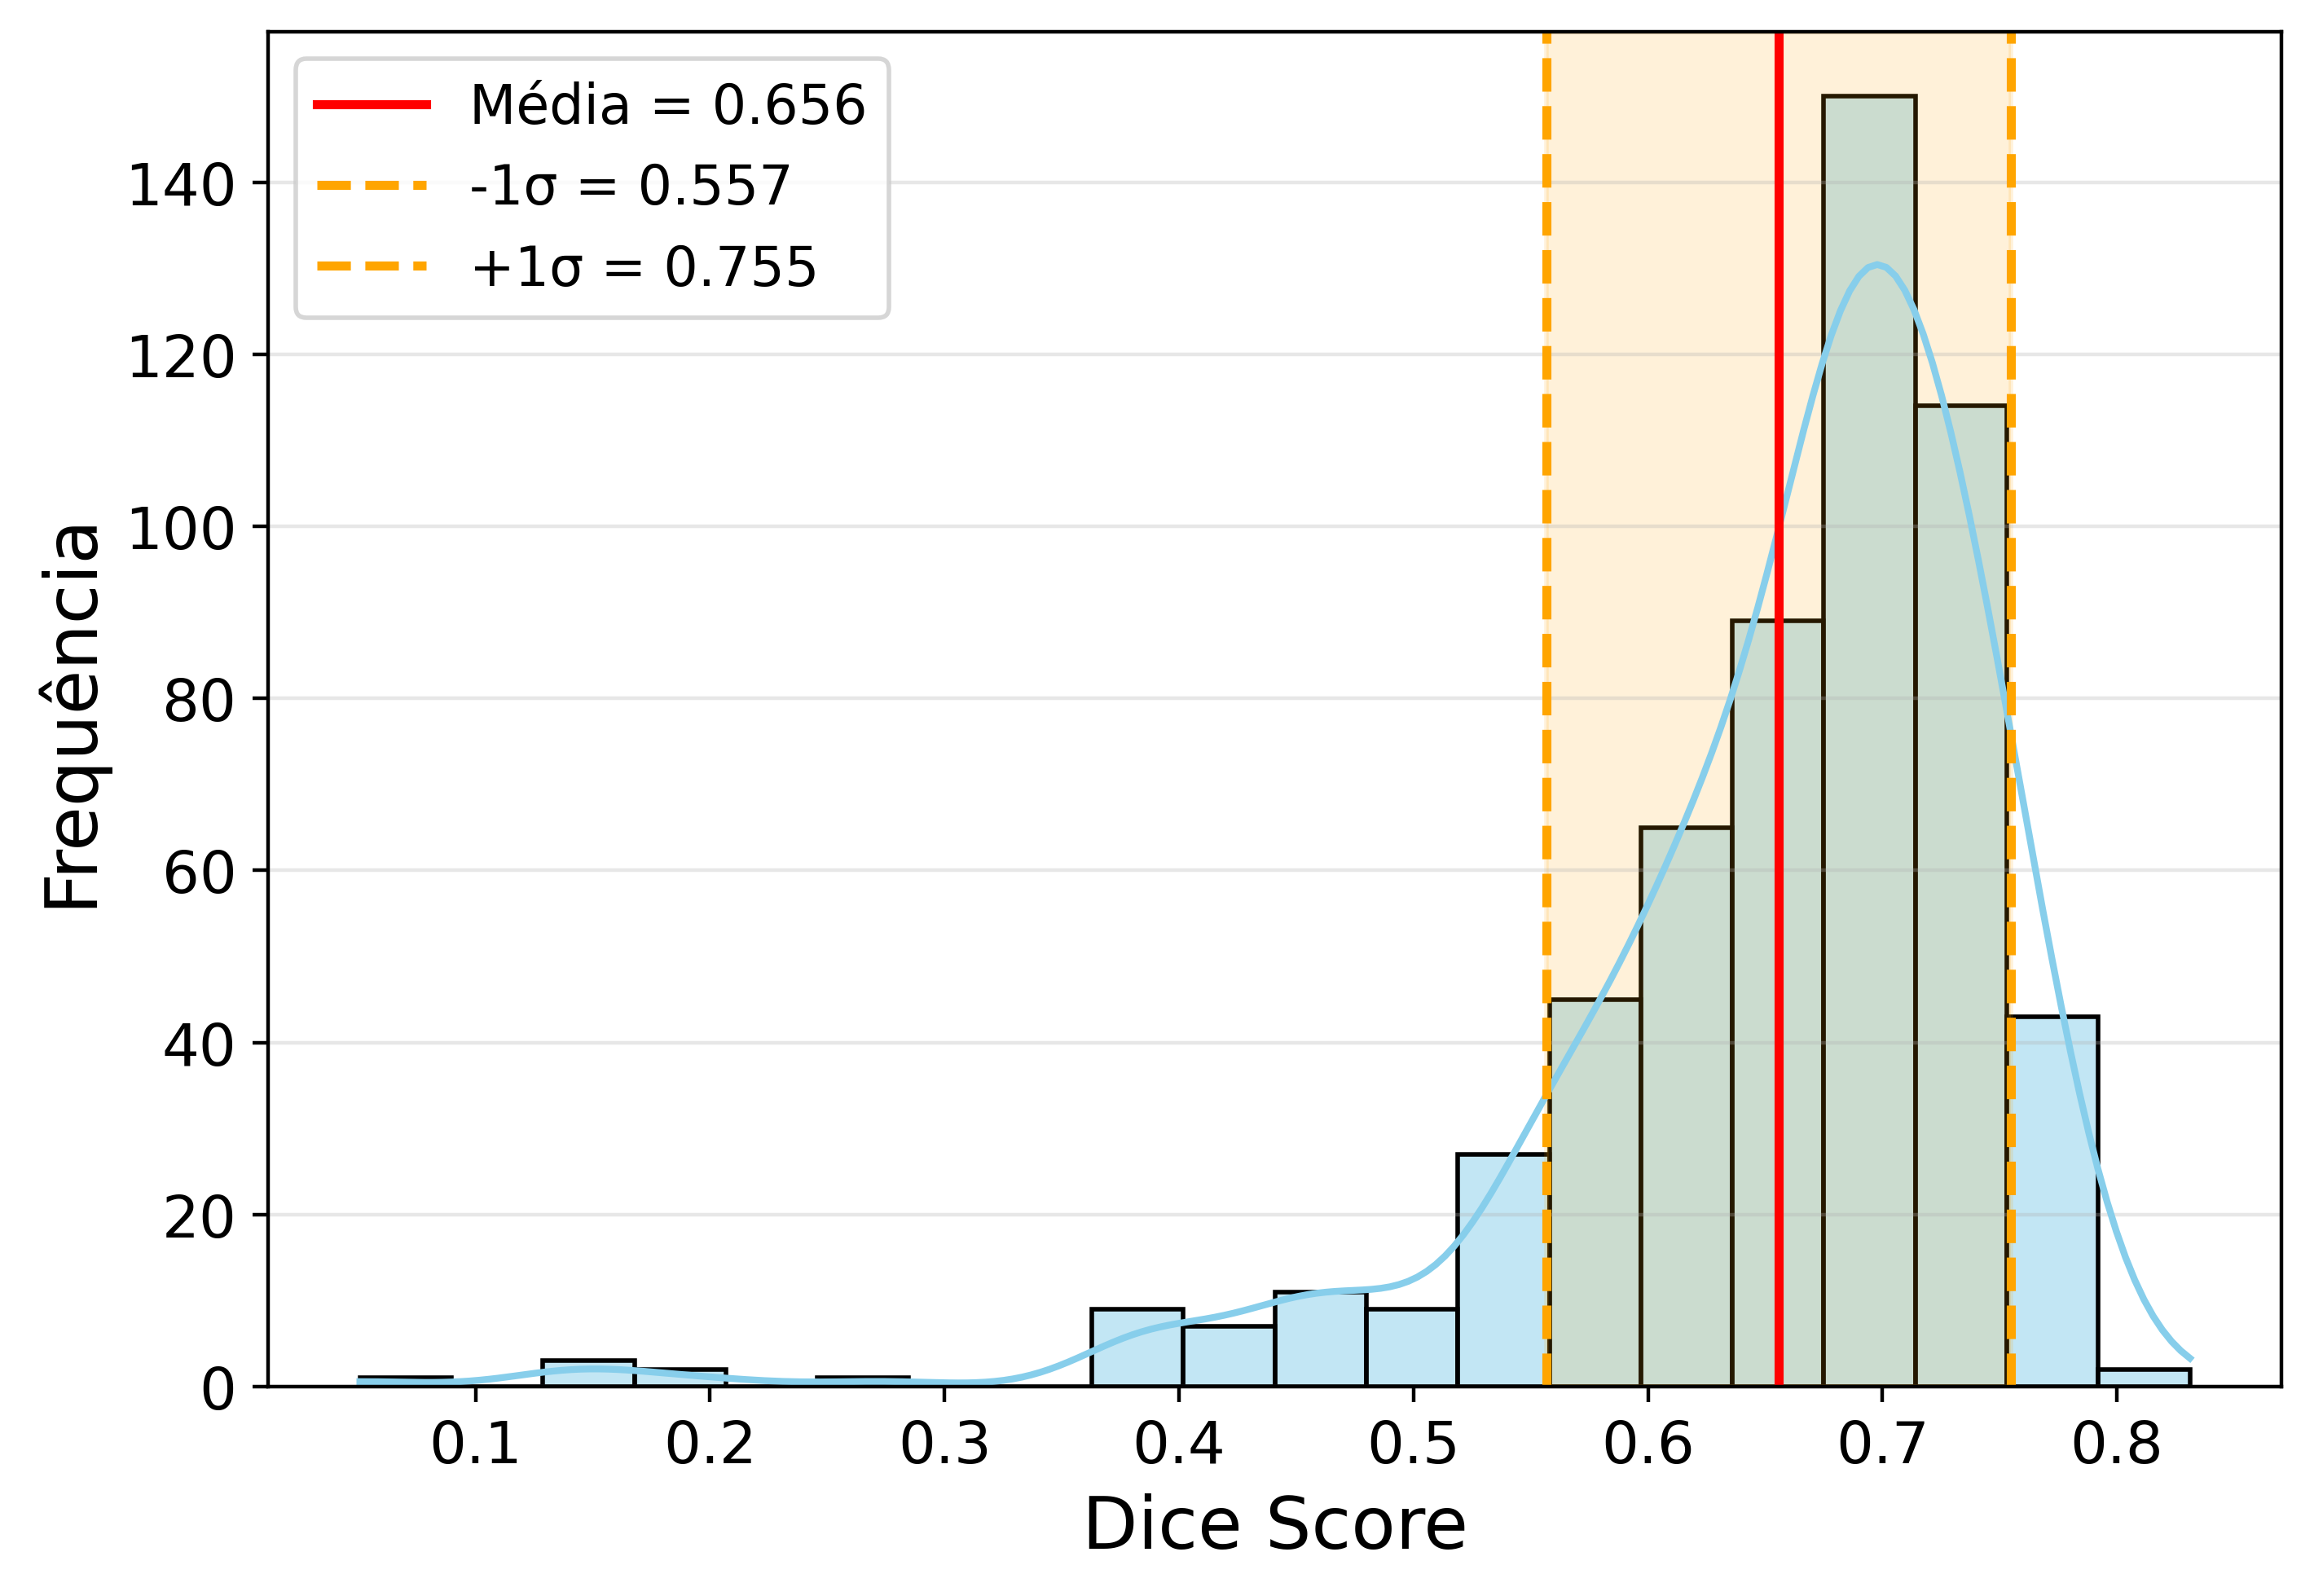

In [21]:
mid_dice_correct_ostia_df = build_mid_dice_subset(only_correct_ostia=True)
_, correct_ostia_stats = plot_dice_distribution_for_publication(
    mid_dice_correct_ostia_df["dice_artery"],
    output_path=None,
    dpi=TEMP_FIGURE_DPI,
)
print(correct_ostia_stats)

## Conclusão

Os resumos de status, distância e Dice permitem avaliar os splits disponíveis e separar o impacto da detecção dos óstios sobre a segmentação arterial.